In [1]:
from intchem import enumerate_ratio_formulas

In [2]:
def test_enumerate_ratio_formulas(chemical_formula="Ag0.33Cl0.67", all_oxi_states=False, eps=0.02, N1=1, N2=20):
    import pandas as pd
    import pickle
    import os
    results = []
    for N in range(N1, N2+1):
        cands = enumerate_ratio_formulas(chemical_formula, N=N, eps=eps, metric="linf",all_oxi_states=all_oxi_states)
        for c in cands:
            results.append({
                "N": N,
                "unreduced_formula": c.unreduced_formula,
                "reduced_formula": c.reduced_formula,
                "error": c.err_linf,
                "ion_guesses": c.ion_guesses,
            })
    df = pd.DataFrame(results)
    dir_path = "data"
    filename = f"{dir_path}/{chemical_formula}.pickle"
    os.makedirs( dir_path, exist_ok=True)
    with open(filename,"wb") as f:
        pickle.dump(df,f)
    return df

def plot_candidates(chemical_formula = "PbTiO3", N2=70):
    import numpy as np
    import pandas as pd
    
    candidates = []
    for eps in np.logspace(-3,-1,10):
        _df = test_enumerate_ratio_formulas(chemical_formula = chemical_formula, eps=eps, N2=N2)
        candidates.append({"eps":eps, "N":len(_df)})
        
    df_plot = pd.DataFrame(candidates)
    ax = df_plot.plot.scatter(x="eps",y="N")
    ax.set_title(f"number of candidates for {chemical_formula}, upto N2={N2}")
    ax.set_ylabel("number of candidates")
    ax.set_xscale("log")


In [3]:
test_enumerate_ratio_formulas(chemical_formula = "Ag0.33Cl0.67")


,N,unreduced_formula,reduced_formula,error,ion_guesses
0,3,AgCl2,AgCl2,0.003333,"({'Ag': 2.0, 'Cl': -1.0},)"
1,6,Ag2Cl4,AgCl2,0.003333,"({'Ag': 2.0, 'Cl': -1.0},)"
2,9,Ag3Cl6,AgCl2,0.003333,"({'Ag': 2.0, 'Cl': -1.0},)"
3,12,Ag4Cl8,AgCl2,0.003333,"({'Ag': 2.0, 'Cl': -1.0},)"
4,15,Ag5Cl10,AgCl2,0.003333,"({'Ag': 2.0, 'Cl': -1.0},)"
5,16,Ag5Cl11,Ag5Cl11,0.017500,"({'Ag': 2.2, 'Cl': -1.0},)"
6,18,Ag6Cl12,AgCl2,0.003333,"({'Ag': 2.0, 'Cl': -1.0},)"
7,19,Ag6Cl13,Ag6Cl13,0.014211,"({'Ag': 2.1666666666666665, 'Cl': -1.0},)"


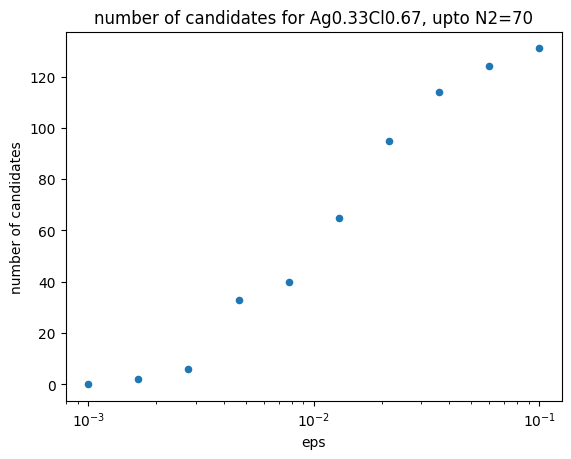

In [4]:
plot_candidates(chemical_formula = "Ag0.33Cl0.67")

In [5]:
test_enumerate_ratio_formulas(chemical_formula = "Na0.45Cl0.55")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,9,Na4Cl5,Na4Cl5,0.005556,()
1,11,Na5Cl6,Na5Cl6,0.004545,()
2,13,Na6Cl7,Na6Cl7,0.011538,()
3,15,Na7Cl8,Na7Cl8,0.016667,()
4,16,Na7Cl9,Na7Cl9,0.012500,()
5,18,Na8Cl10,Na4Cl5,0.005556,()
6,20,Na9Cl11,Na9Cl11,0.000000,()


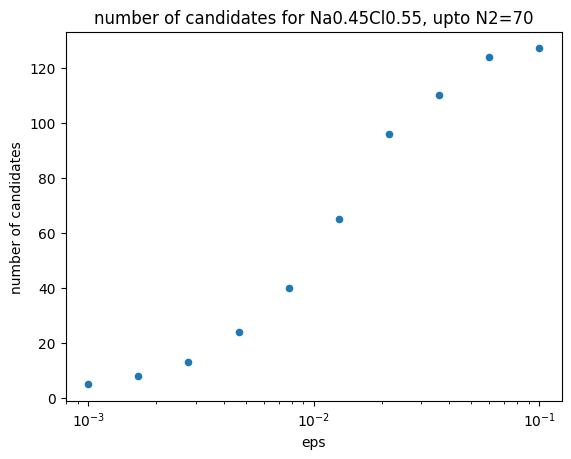

In [6]:
plot_candidates(chemical_formula = "Na0.45Cl0.55")

In [7]:
test_enumerate_ratio_formulas(chemical_formula = "Fe2O3")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,5,Fe2O3,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"
1,10,Fe4O6,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"
2,12,Fe5O7,Fe5O7,0.016667,"({'Fe': 2.8, 'O': -2.0},)"
3,13,Fe5O8,Fe5O8,0.015385,()
4,15,Fe6O9,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"
5,17,Fe7O10,Fe7O10,0.011765,"({'Fe': 2.857142857142857, 'O': -2.0},)"
6,18,Fe7O11,Fe7O11,0.011111,()
7,20,Fe8O12,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"


In [8]:
test_enumerate_ratio_formulas(chemical_formula = "Fe3O4")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,7,Fe3O4,Fe3O4,0.000000,"({'Fe': 2.6666666666666665, 'O': -2.0},)"
1,9,Fe4O5,Fe4O5,0.015873,"({'Fe': 2.5, 'O': -2.0},)"
2,12,Fe5O7,Fe5O7,0.011905,"({'Fe': 2.8, 'O': -2.0},)"
3,14,Fe6O8,Fe3O4,0.000000,"({'Fe': 2.6666666666666665, 'O': -2.0},)"
4,16,Fe7O9,Fe7O9,0.008929,"({'Fe': 2.5714285714285716, 'O': -2.0},)"
5,17,Fe7O10,Fe7O10,0.016807,"({'Fe': 2.857142857142857, 'O': -2.0},)"
6,18,Fe8O10,Fe4O5,0.015873,"({'Fe': 2.5, 'O': -2.0},)"
7,19,Fe8O11,Fe8O11,0.007519,"({'Fe': 2.75, 'O': -2.0},)"


In [9]:
test_enumerate_ratio_formulas(chemical_formula = "Na2Cl3")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,5,Na2Cl3,Na2Cl3,0.000000,()
1,10,Na4Cl6,Na2Cl3,0.000000,()
2,12,Na5Cl7,Na5Cl7,0.016667,()
3,13,Na5Cl8,Na5Cl8,0.015385,()
4,15,Na6Cl9,Na2Cl3,0.000000,()
5,17,Na7Cl10,Na7Cl10,0.011765,()
6,18,Na7Cl11,Na7Cl11,0.011111,()
7,20,Na8Cl12,Na2Cl3,0.000000,()


In [10]:
test_enumerate_ratio_formulas(chemical_formula = "Fe2O3")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,5,Fe2O3,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"
1,10,Fe4O6,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"
2,12,Fe5O7,Fe5O7,0.016667,"({'Fe': 2.8, 'O': -2.0},)"
3,13,Fe5O8,Fe5O8,0.015385,()
4,15,Fe6O9,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"
5,17,Fe7O10,Fe7O10,0.011765,"({'Fe': 2.857142857142857, 'O': -2.0},)"
6,18,Fe7O11,Fe7O11,0.011111,()
7,20,Fe8O12,Fe2O3,0.000000,"({'Fe': 3.0, 'O': -2.0},)"


In [11]:
test_enumerate_ratio_formulas(chemical_formula = "Nd2Fe14B")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,16,Nd2Fe13B,Nd2Fe13B,0.011029,()
1,17,Nd2Fe14B,Nd2Fe14B,0.000000,()
2,18,Nd2Fe15B,Nd2Fe15B,0.009804,()
3,19,Nd2Fe16B,Nd2Fe16B,0.018576,()


In [12]:
test_enumerate_ratio_formulas(chemical_formula = "PbTiO3")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,5,PbTiO3,TiPbO3,0.0,"({'Ti': 4.0, 'Pb': 2.0, 'O': -2.0}, {'Ti': 2.0..."
1,10,Pb2Ti2O6,TiPbO3,0.0,"({'Ti': 4.0, 'Pb': 2.0, 'O': -2.0}, {'Ti': 2.0..."
2,15,Pb3Ti3O9,TiPbO3,0.0,"({'Ti': 4.0, 'Pb': 2.0, 'O': -2.0}, {'Ti': 2.0..."
3,20,Pb4Ti4O12,TiPbO3,0.0,"({'Ti': 4.0, 'Pb': 2.0, 'O': -2.0}, {'Ti': 2.0..."


In [13]:
test_enumerate_ratio_formulas(chemical_formula = "LiFePO4")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,7,LiFePO4,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
1,14,Li2Fe2P2O8,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."


In [14]:
for eps in [0.001, 0.005, 0.01,0.05,0.1]:
    print(f"eps={eps}")
    display(test_enumerate_ratio_formulas(chemical_formula = "LiFePO4", eps=eps))

eps=0.001


,N,unreduced_formula,reduced_formula,error,ion_guesses
0,7,LiFePO4,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
1,14,Li2Fe2P2O8,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."


eps=0.005


,N,unreduced_formula,reduced_formula,error,ion_guesses
0,7,LiFePO4,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
1,14,Li2Fe2P2O8,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."


eps=0.01


,N,unreduced_formula,reduced_formula,error,ion_guesses
0,7,LiFePO4,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
1,14,Li2Fe2P2O8,LiFePO4,0.0,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."


eps=0.05


,N,unreduced_formula,reduced_formula,error,ion_guesses
0,7,LiFePO4,LiFePO4,0.000000,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
1,13,Li2Fe2P2O7,Li2Fe2P2O7,0.032967,"({'Li': 1.0, 'Fe': 2.0, 'P': 4.0, 'O': -2.0}, ..."
2,14,Li2Fe2P2O8,LiFePO4,0.000000,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
3,15,Li2Fe2P2O9,Li2Fe2P2O9,0.028571,"({'Li': 1.0, 'Fe': 3.0, 'P': 5.0, 'O': -2.0},)"
4,16,Li2Fe2P3O9,Li2Fe2(PO3)3,0.044643,"({'Li': 1.0, 'Fe': 2.5, 'P': 3.666666666666666..."
5,16,Li2Fe3P2O9,Li2Fe3P2O9,0.044643,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
6,16,Li3Fe2P2O9,Li3Fe2P2O9,0.044643,"({'Li': 1.0, 'Fe': 2.5, 'P': 5.0, 'O': -2.0}, ..."
7,17,Li2Fe2P3O10,Li2Fe2P3O10,0.033613,"({'Li': 1.0, 'Fe': 2.5, 'P': 4.333333333333333..."
8,17,Li2Fe3P2O10,Li2Fe3(PO5)2,0.033613,"({'Li': 1.0, 'Fe': 2.6666666666666665, 'P': 5...."
9,17,Li3Fe2P2O10,Li3Fe2(PO5)2,0.033613,()


eps=0.1


,N,unreduced_formula,reduced_formula,error,ion_guesses
0,6,LiFePO3,LiFePO3,0.071429,"({'Li': 1.0, 'Fe': 2.0, 'P': 3.0, 'O': -2.0},)"
1,7,LiFePO4,LiFePO4,0.000000,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
2,8,LiFePO5,LiFePO5,0.053571,()
3,9,Li2FePO5,Li2FePO5,0.079365,"({'Li': 1.0, 'Fe': 3.0, 'P': 5.0, 'O': -2.0},)"
4,9,LiFe2PO5,LiFe2PO5,0.079365,"({'Li': 1.0, 'Fe': 2.0, 'P': 5.0, 'O': -2.0}, ..."
5,9,LiFeP2O5,LiFeP2O5,0.079365,"({'Li': 1.0, 'Fe': 3.0, 'P': 3.0, 'O': -2.0}, ..."
6,9,LiFePO6,LiFePO6,0.095238,()
7,10,Li2FePO6,Li2FePO6,0.057143,()
8,10,LiFeP2O6,LiFe(PO3)2,0.057143,"({'Li': 1.0, 'Fe': 3.0, 'P': 4.0, 'O': -2.0}, ..."
9,10,LiFe2PO6,LiFe2PO6,0.057143,"({'Li': 1.0, 'Fe': 3.0, 'P': 5.0, 'O': -2.0},)"


In [15]:
test_enumerate_ratio_formulas(chemical_formula = "LiFeO2")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,4,LiFeO2,LiFeO2,0.0,"({'Li': 1.0, 'Fe': 3.0, 'O': -2.0},)"
1,8,Li2Fe2O4,LiFeO2,0.0,"({'Li': 1.0, 'Fe': 3.0, 'O': -2.0},)"
2,12,Li3Fe3O6,LiFeO2,0.0,"({'Li': 1.0, 'Fe': 3.0, 'O': -2.0},)"
3,16,Li4Fe4O8,LiFeO2,0.0,"({'Li': 1.0, 'Fe': 3.0, 'O': -2.0},)"
4,20,Li5Fe5O10,LiFeO2,0.0,"({'Li': 1.0, 'Fe': 3.0, 'O': -2.0},)"


In [16]:
test_enumerate_ratio_formulas(chemical_formula = "Li2FeO3")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,6,Li2FeO3,Li2FeO3,0.000000,()
1,12,Li4Fe2O6,Li2FeO3,0.000000,()
2,18,Li6Fe3O9,Li2FeO3,0.000000,()
3,20,Li7Fe3O10,Li7Fe3O10,0.016667,()


In [17]:
test_enumerate_ratio_formulas(chemical_formula = "Li2O2")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,2,LiO,Li2O2,0.0,()
1,4,Li2O2,Li2O2,0.0,()
2,6,Li3O3,Li2O2,0.0,()
3,8,Li4O4,Li2O2,0.0,()
4,10,Li5O5,Li2O2,0.0,()
5,12,Li6O6,Li2O2,0.0,()
6,14,Li7O7,Li2O2,0.0,()
7,16,Li8O8,Li2O2,0.0,()
8,18,Li9O9,Li2O2,0.0,()
9,20,Li10O10,Li2O2,0.0,()


In [18]:
test_enumerate_ratio_formulas(chemical_formula = "LiO8")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,8,LiO7,LiO7,0.013889,()
1,9,LiO8,LiO8,0.000000,()
2,10,LiO9,LiO9,0.011111,()
3,16,Li2O14,LiO7,0.013889,()
4,17,Li2O15,Li2O15,0.006536,()
5,18,Li2O16,LiO8,0.000000,()
6,19,Li2O17,Li2O17,0.005848,()
7,20,Li2O18,LiO9,0.011111,()


In [19]:
test_enumerate_ratio_formulas(chemical_formula = "Ni3Pt")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,4,Ni3Pt,Ni3Pt,0.000000,()
1,8,Ni6Pt2,Ni3Pt,0.000000,()
2,12,Ni9Pt3,Ni3Pt,0.000000,()
3,13,Ni10Pt3,Ni10Pt3,0.019231,()
4,15,Ni11Pt4,Ni11Pt4,0.016667,()
5,16,Ni12Pt4,Ni3Pt,0.000000,()
6,17,Ni13Pt4,Ni13Pt4,0.014706,()
7,19,Ni14Pt5,Ni14Pt5,0.013158,()
8,20,Ni15Pt5,Ni3Pt,0.000000,()


In [20]:
test_enumerate_ratio_formulas(chemical_formula = "NiPt")

,N,unreduced_formula,reduced_formula,error,ion_guesses
0,2,NiPt,NiPt,0.0,()
1,4,Ni2Pt2,NiPt,0.0,()
2,6,Ni3Pt3,NiPt,0.0,()
3,8,Ni4Pt4,NiPt,0.0,()
4,10,Ni5Pt5,NiPt,0.0,()
5,12,Ni6Pt6,NiPt,0.0,()
6,14,Ni7Pt7,NiPt,0.0,()
7,16,Ni8Pt8,NiPt,0.0,()
8,18,Ni9Pt9,NiPt,0.0,()
9,20,Ni10Pt10,NiPt,0.0,()
